In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import PowerTransformer

warnings.filterwarnings('ignore')
# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False


In [2]:
# 读取数据
df = pd.read_excel(
    r'E:\pycharm all files\眼动数据处理\GSR\完整SCL处理分析\文件提取&GSR分解&去除异常值&绘图\GSR_SCL_AllEvents_cleanForPlot.xlsx')
df

,组别,姓名,飞行天数,阶段,data
0,A,付瑞晗,2,1,1.383278e+06
1,A,付瑞晗,2,1,1.383205e+06
2,A,付瑞晗,2,1,1.383130e+06
3,A,付瑞晗,2,1,1.383055e+06
4,A,付瑞晗,2,1,1.382978e+06
...,...,...,...,...,...
399461,B,陈妍,7,qifei,9.616426e+05
399462,B,陈妍,7,qifei,9.616319e+05
399463,B,陈妍,7,qifei,9.616223e+05
399464,B,陈妍,7,qifei,9.616137e+05


In [35]:
len(df.姓名.unique())

32

In [36]:
# 查看缺失值
print('缺失值个数：', df.isnull().sum().sum())
# 查看异常值
df1 = df[df['data'].isnull()]
df1

缺失值个数： 0


,组别,姓名,飞行天数,阶段,data


In [40]:
# 重置列名
df.columns = ['组别', '受试者', '飞行天数', '阶段', 'SCL']

# 将阶段为喝酒的行删掉
# df = df[df['阶段'] != 'hejiu']

# 重命名阶段
# df['阶段'] = df['阶段'].replace(['1', '2', '3', '4'], ['turn1', 'turn2', 'turn3', 'turn4'])
df['阶段'] = df['阶段'].replace(['1', '2', '3', '4'], '转弯')
df['阶段'] = df['阶段'].replace('qifei', '起飞')
df['阶段'] = df['阶段'].replace('jiangluo', '降落')
df['阶段'] = df['阶段'].replace('hejiu', '静息')

df

,组别,受试者,飞行天数,阶段,SCL
0,A,付瑞晗,2,转弯,1.383278e+06
1,A,付瑞晗,2,转弯,1.383205e+06
2,A,付瑞晗,2,转弯,1.383130e+06
3,A,付瑞晗,2,转弯,1.383055e+06
4,A,付瑞晗,2,转弯,1.382978e+06
...,...,...,...,...,...
399461,B,陈妍,7,起飞,9.616426e+05
399462,B,陈妍,7,起飞,9.616319e+05
399463,B,陈妍,7,起飞,9.616223e+05
399464,B,陈妍,7,起飞,9.616137e+05


In [41]:
# 按阶段、组别、受试者、飞行天数分组，计算均值和中位数
df = df.groupby(['阶段', '组别', '受试者', '飞行天数'], as_index=False)['SCL'].agg(
    SCL均值='mean',
    SCL中位数='median'
)

df

# # 保存到新的 Excel 文件
# df.to_excel("GSR_SCL_阶段汇总数据.xlsx", index=False)
# 
# print("已生成文件：GSR_SCL_阶段汇总数据.xlsx")


,阶段,组别,受试者,飞行天数,SCL均值,SCL中位数
0,起飞,A,付瑞晗,2,1.400061e+06,1.399849e+06
1,起飞,A,付瑞晗,3,1.465199e+06,1.466115e+06
2,起飞,A,付瑞晗,4,1.344235e+06,1.347145e+06
3,起飞,A,付瑞晗,5,1.973538e+06,1.968505e+06
4,起飞,A,付瑞晗,6,2.711935e+06,2.688735e+06
...,...,...,...,...,...,...
762,静息,B,陈妍,3,6.464258e+05,6.482130e+05
763,静息,B,陈妍,4,1.068071e+06,1.068074e+06
764,静息,B,陈妍,5,2.102255e+09,2.595939e+07
765,静息,B,陈妍,6,8.789637e+05,8.789828e+05


In [42]:
# df_median使用ln(SCL)对数变换
df['SCL_median_ln'] = np.log(df['SCL中位数'])
df['SCL_mean_ln'] = np.log(df['SCL均值'])
df

,阶段,组别,受试者,飞行天数,SCL均值,SCL中位数,SCL_median_ln,SCL_mean_ln
0,起飞,A,付瑞晗,2,1.400061e+06,1.399849e+06,14.151875,14.152026
1,起飞,A,付瑞晗,3,1.465199e+06,1.466115e+06,14.198127,14.197502
2,起飞,A,付瑞晗,4,1.344235e+06,1.347145e+06,14.113498,14.111336
3,起飞,A,付瑞晗,5,1.973538e+06,1.968505e+06,14.492785,14.495339
4,起飞,A,付瑞晗,6,2.711935e+06,2.688735e+06,14.804582,14.813173
...,...,...,...,...,...,...,...,...
762,静息,B,陈妍,3,6.464258e+05,6.482130e+05,13.381975,13.379214
763,静息,B,陈妍,4,1.068071e+06,1.068074e+06,13.881367,13.881365
764,静息,B,陈妍,5,2.102255e+09,2.595939e+07,17.072044,21.466276
765,静息,B,陈妍,6,8.789637e+05,8.789828e+05,13.686521,13.686499


In [43]:
pt = PowerTransformer(method='yeo-johnson')
df[['SCL_median_yj', 'SCL_mean_yj']] = pt.fit_transform(df[['SCL中位数', 'SCL均值']])
df

,阶段,组别,受试者,飞行天数,SCL均值,SCL中位数,SCL_median_ln,SCL_mean_ln,SCL_median_yj,SCL_mean_yj
0,起飞,A,付瑞晗,2,1.400061e+06,1.399849e+06,14.151875,14.152026,0.691144,-0.009160
1,起飞,A,付瑞晗,3,1.465199e+06,1.466115e+06,14.198127,14.197502,0.762797,-0.007582
2,起飞,A,付瑞晗,4,1.344235e+06,1.347145e+06,14.113498,14.111336,0.632531,-0.010526
3,起飞,A,付瑞晗,5,1.973538e+06,1.968505e+06,14.492785,14.495339,1.246390,0.004244
4,起飞,A,付瑞晗,6,2.711935e+06,2.688735e+06,14.804582,14.813173,1.813048,0.020250
...,...,...,...,...,...,...,...,...,...,...
762,静息,B,陈妍,3,6.464258e+05,6.482130e+05,13.381975,13.379214,-0.351593,-0.029015
763,静息,B,陈妍,4,1.068071e+06,1.068074e+06,13.881367,13.881365,0.293669,-0.017491
764,静息,B,陈妍,5,2.102255e+09,2.595939e+07,17.072044,21.466276,8.322072,12.398535
765,静息,B,陈妍,6,8.789637e+05,8.789828e+05,13.686521,13.686499,0.028951,-0.022499


In [44]:
# 替换组别名称
df["组别"] = df["组别"].replace({
    "A": "Alcohol",
    "B": "Control"
})
df

,阶段,组别,受试者,飞行天数,SCL均值,SCL中位数,SCL_median_ln,SCL_mean_ln,SCL_median_yj,SCL_mean_yj
0,起飞,Alcohol,付瑞晗,2,1.400061e+06,1.399849e+06,14.151875,14.152026,0.691144,-0.009160
1,起飞,Alcohol,付瑞晗,3,1.465199e+06,1.466115e+06,14.198127,14.197502,0.762797,-0.007582
2,起飞,Alcohol,付瑞晗,4,1.344235e+06,1.347145e+06,14.113498,14.111336,0.632531,-0.010526
3,起飞,Alcohol,付瑞晗,5,1.973538e+06,1.968505e+06,14.492785,14.495339,1.246390,0.004244
4,起飞,Alcohol,付瑞晗,6,2.711935e+06,2.688735e+06,14.804582,14.813173,1.813048,0.020250
...,...,...,...,...,...,...,...,...,...,...
762,静息,Control,陈妍,3,6.464258e+05,6.482130e+05,13.381975,13.379214,-0.351593,-0.029015
763,静息,Control,陈妍,4,1.068071e+06,1.068074e+06,13.881367,13.881365,0.293669,-0.017491
764,静息,Control,陈妍,5,2.102255e+09,2.595939e+07,17.072044,21.466276,8.322072,12.398535
765,静息,Control,陈妍,6,8.789637e+05,8.789828e+05,13.686521,13.686499,0.028951,-0.022499


In [45]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df['SCL_median_yj_z'] = scaler.fit_transform(df[['SCL_median_yj']])
df['SCL_mean_yj_z'] = scaler.fit_transform(df[['SCL_mean_yj']])

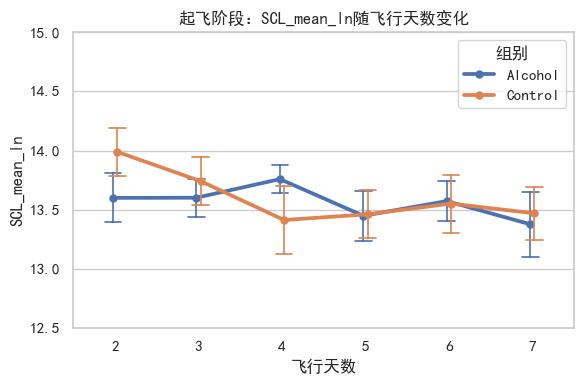

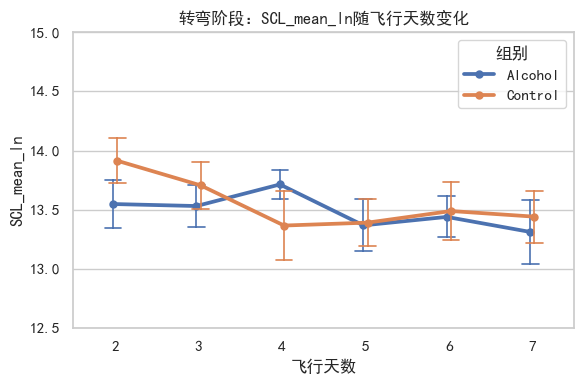

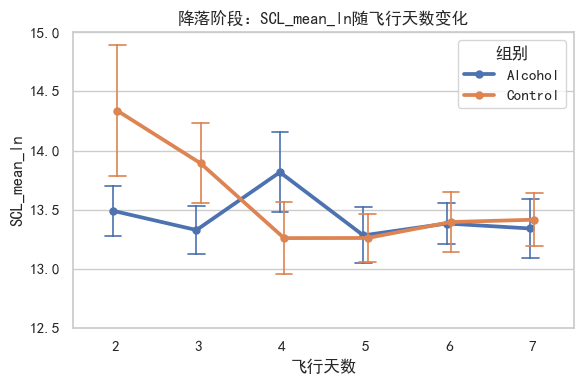

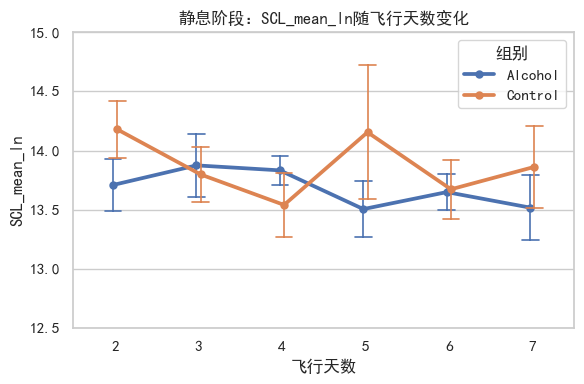

In [46]:
# 设定绘图风格
sns.set(style="whitegrid", font="SimHei")  # 支持中文显示

# 三个阶段
phases = df["阶段"].unique()
label = 'SCL_mean_ln'
# 建立图表
for phase in phases:
    plt.figure(figsize=(6, 4))

    # if phase != "降落":
    #     continue
    # 筛选该阶段数据
    sub_df = df[df["阶段"] == phase]

    sns.pointplot(
        data=sub_df,
        x="飞行天数",
        y=label,
        hue="组别",
        # errorbar=("ci", 95), # 误差线显示 95% 置信区间 # 或 ("se", 1)
        errorbar=("se", 1),  # 画标准误 误差线显示 ±1 标准误
        dodge=True,
        join=True,
        capsize=0.2,  # 控制小横线长度 (相对比例)
        errwidth=1.2,  # 误差线粗细，可调
        markersize=4
    )

    plt.title(f"{phase}阶段：{label}随飞行天数变化")
    plt.xlabel("飞行天数")
    plt.ylabel(label)
    plt.ylim(12.5, 15)
    plt.legend(title="组别")
    plt.tight_layout()
    plt.show()


In [47]:
df[(df['阶段'] == '降落')]

,阶段,组别,受试者,飞行天数,SCL均值,SCL中位数,SCL_median_ln,SCL_mean_ln,SCL_median_yj,SCL_mean_yj,SCL_median_yj_z,SCL_mean_yj_z
384,降落,Alcohol,付瑞晗,2,1.334699e+06,1.335060e+06,14.104487,14.104217,0.618876,-0.010761,0.618876,-0.010761
385,降落,Alcohol,付瑞晗,3,1.433130e+06,1.438420e+06,14.179056,14.175371,0.733117,-0.008357,0.733117,-0.008357
386,降落,Alcohol,付瑞晗,4,1.285809e+06,1.284242e+06,14.065679,14.066899,0.560547,-0.011970,0.560547,-0.011970
387,降落,Alcohol,付瑞晗,5,1.881739e+06,1.880646e+06,14.447126,14.447707,1.168283,0.002166,1.168283,0.002166
388,降落,Alcohol,付瑞晗,6,1.644461e+06,1.644344e+06,14.312852,14.312923,0.945412,-0.003318,0.945412,-0.003318
...,...,...,...,...,...,...,...,...,...,...,...,...
570,降落,Control,陈妍,3,5.926664e+05,5.926925e+05,13.292431,13.292387,-0.456269,-0.030593,-0.456269,-0.030593
571,降落,Control,陈妍,4,8.148878e+05,8.151237e+05,13.611095,13.610806,-0.068957,-0.024250,-0.068957,-0.024250
572,降落,Control,陈妍,5,1.147268e+06,1.146911e+06,13.952582,13.952894,0.394831,-0.015455,0.394831,-0.015455
573,降落,Control,陈妍,6,8.406935e+05,8.417503e+05,13.643239,13.641982,-0.027535,-0.023541,-0.027535,-0.023541


In [48]:
# df4 = df[(df['阶段'] == '降落') & (df['受试者'] == '周鑫颜') & (df['飞行天数'] == 2)]
# #去掉df中的df4
# df = df[df.index.isin(df4.index) == False]
# df
# # 输出